## 0. Installation et vérification de l'environnement
On vérifie les versions des bibliothèques et la puissance disponible (GPU, RAM, disque)
pour calibrer la taille du projet.

In [1]:
import torch
import torchvision
import platform
import psutil
import shutil

print("Python       :", platform.python_version())
print("PyTorch      :", torch.__version__)
print("Torchvision  :", torchvision.__version__)
print("GPU dispo    :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Nom du GPU   :", torch.cuda.get_device_name(0))
    memoire = torch.cuda.get_device_properties(0).total_memory / 1e9
    print("Mémoire GPU  :", round(memoire, 1), "Go")

print("RAM          :", round(psutil.virtual_memory().total / 1e9, 1), "Go")
print("Disque libre :", round(shutil.disk_usage("/").free / 1e9, 1), "Go")

Python       : 3.13.15
PyTorch      : 2.11.0+cu130
Torchvision  : 0.26.0+cu130
GPU dispo    : True
Nom du GPU   : Tesla T4
Mémoire GPU  : 15.6 Go
RAM          : 13.6 Go
Disque libre : 75.3 Go


In [2]:
from google.colab import drive
import os

drive.mount("/content/drive")

# Dossier du projet sur ton Drive : tout ce qu'on y met survit aux déconnexions
PROJET = "/content/drive/MyDrive/projet_frelon"

for sous_dossier in ["data/images", "models", "outputs"]:
    os.makedirs(os.path.join(PROJET, sous_dossier), exist_ok=True)

print("Contenu du projet :", os.listdir(PROJET))

Mounted at /content/drive
Contenu du projet : ['data', 'models', 'outputs']


In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from PIL import Image

# Graine aléatoire fixe : les résultats seront identiques à chaque exécution
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Tous les calculs iront sur le GPU s'il existe, sinon sur le processeur
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("On travaille sur :", DEVICE)

On travaille sur : cuda


## 1. Collecte des données (API iNaturalist)
iNaturalist est une plateforme de sciences participatives : des citoyens photographient
des espèces, et la communauté valide l'identification. On ne garde que les observations
"research grade" (identification confirmée par plusieurs personnes), faites en France,
avec photo.

In [3]:
import time

API = "https://api.inaturalist.org/v1"

# Nos 6 classes : nom de classe -> nom scientifique dans iNaturalist
ESPECES = {
    "frelon_asiatique": "Vespa velutina",
    "frelon_europeen":  "Vespa crabro",
    "guepe":            "Vespula",          # genre entier (les espèces sont indiscernables en photo)
    "abeille":          "Apis mellifera",
    "bourdon":          "Bombus terrestris",
    "volucelle":        "Volucella zonaria", # la mouche qui imite le frelon
}

# 1) Trouver l'identifiant de la France dans iNaturalist
lieux = requests.get(f"{API}/places/autocomplete", params={"q": "France"}).json()["results"]
france = next(p for p in lieux if p["name"] == "France")
PLACE_ID = france["id"]
print("France -> place_id =", PLACE_ID, "|", france["display_name"], "\n")

# 2) Pour chaque espèce : trouver son identifiant et compter les observations en France
TAXONS = {}
for classe, nom in ESPECES.items():
    resultats = requests.get(f"{API}/taxa", params={"q": nom}).json()["results"]
    taxon = next(t for t in resultats if t["name"] == nom)

    nb = requests.get(f"{API}/observations", params={
        "taxon_id": taxon["id"],
        "place_id": PLACE_ID,
        "quality_grade": "research",
        "photos": "true",
        "per_page": 0,          # on ne veut que le nombre total, pas les observations
    }).json()["total_results"]

    TAXONS[classe] = taxon["id"]
    print(f"{classe:17} {nom:18} id={taxon['id']:<8} rang={taxon['rank']:8} obs. France = {nb}")
    time.sleep(1)               # on respecte l'API : une requête par seconde

France -> place_id = 6753 | France 

frelon_asiatique  Vespa velutina     id=119019   rang=species  obs. France = 7409
frelon_europeen   Vespa crabro       id=54327    rang=species  obs. France = 5231
guepe             Vespula            id=61356    rang=genus    obs. France = 2677
abeille           Apis mellifera     id=47219    rang=species  obs. France = 14373
bourdon           Bombus terrestris  id=57516    rang=species  obs. France = 1187
volucelle         Volucella zonaria  id=343983   rang=species  obs. France = 3461


### 1.2 Téléchargement des images
Pour chaque espèce, on récupère 400 observations validées en France.
Choix importants :
- une seule photo par observation (sinon, deux photos du même insecte pourraient
  se retrouver dans l'entraînement ET dans le test → résultats faussement bons) ;
- uniquement des photos sous licence Creative Commons (utilisation légale) ;
- format "medium" (environ 500 px), suffisant puisque le modèle travaille en 224 px.

In [5]:
from io import BytesIO

NB_PAR_CLASSE = 400
LICENCES = "cc0,cc-by,cc-by-nc,cc-by-sa,cc-by-nc-sa,cc-by-nd,cc-by-nc-nd"
DOSSIER_IMAGES = os.path.join(PROJET, "data/images")


def lister_photos(taxon_id, nb):
    """Récupère la liste des photos (url, licence, auteur) d'une espèce, page par page."""
    photos = []
    page = 1
    while len(photos) < nb:
        resultats = requests.get(f"{API}/observations", params={
            "taxon_id": taxon_id,
            "place_id": PLACE_ID,
            "quality_grade": "research",
            "photos": "true",
            "photo_license": LICENCES,
            "per_page": 200,        # maximum autorisé par l'API
            "page": page,
        }).json()["results"]

        if not resultats:           # plus aucune observation disponible
            break

        for obs in resultats:
            photo = obs["photos"][0]  # une seule photo par observation
            photos.append({
                "obs_id": obs["id"],
                "url": photo["url"].replace("square", "medium"),
                "licence": photo["license_code"],
                "auteur": photo["attribution"],
            })
        page += 1
        time.sleep(1)
    return photos[:nb]


metadonnees = []
for classe, taxon_id in TAXONS.items():
    dossier = os.path.join(DOSSIER_IMAGES, classe)
    os.makedirs(dossier, exist_ok=True)

    photos = lister_photos(taxon_id, NB_PAR_CLASSE)
    nb_ok = 0
    for p in photos:
        chemin = os.path.join(dossier, f"{p['obs_id']}.jpg")
        if not os.path.exists(chemin):          # reprise possible si coupure
            try:
                contenu = requests.get(p["url"], timeout=20).content
                Image.open(BytesIO(contenu)).convert("RGB").save(chemin)
            except Exception:
                continue                        # image cassée : on l'ignore
        nb_ok += 1
        metadonnees.append({"classe": classe, "fichier": chemin, **p})

    print(f"{classe:17} : {nb_ok} images")

meta = pd.DataFrame(metadonnees)
meta.to_csv(os.path.join(PROJET, "data/metadonnees.csv"), index=False)
print("\nTotal :", len(meta), "images | métadonnées sauvegardées")

frelon_asiatique  : 400 images
frelon_europeen   : 400 images
guepe             : 400 images
abeille           : 400 images
bourdon           : 400 images
volucelle         : 400 images

Total : 2400 images | métadonnées sauvegardées


Nombre d'images          : 2400
Observations en double   : 0


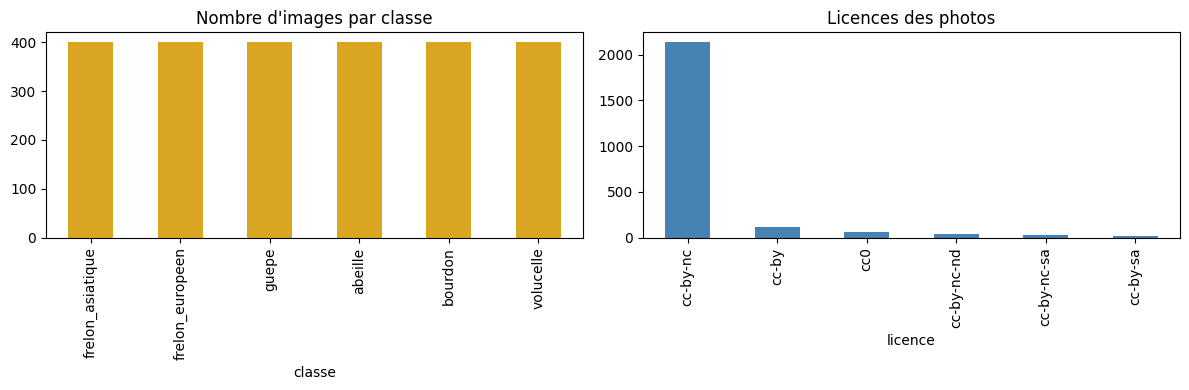

In [6]:
meta = pd.read_csv(os.path.join(PROJET, "data/metadonnees.csv"))
print("Nombre d'images          :", len(meta))
print("Observations en double   :", meta["obs_id"].duplicated().sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

meta["classe"].value_counts().plot.bar(ax=axes[0], color="goldenrod")
axes[0].set_title("Nombre d'images par classe")

meta["licence"].value_counts().plot.bar(ax=axes[1], color="steelblue")
axes[1].set_title("Licences des photos")

plt.tight_layout()
plt.savefig(os.path.join(PROJET, "outputs/eda_repartition.png"), dpi=150)
plt.show()

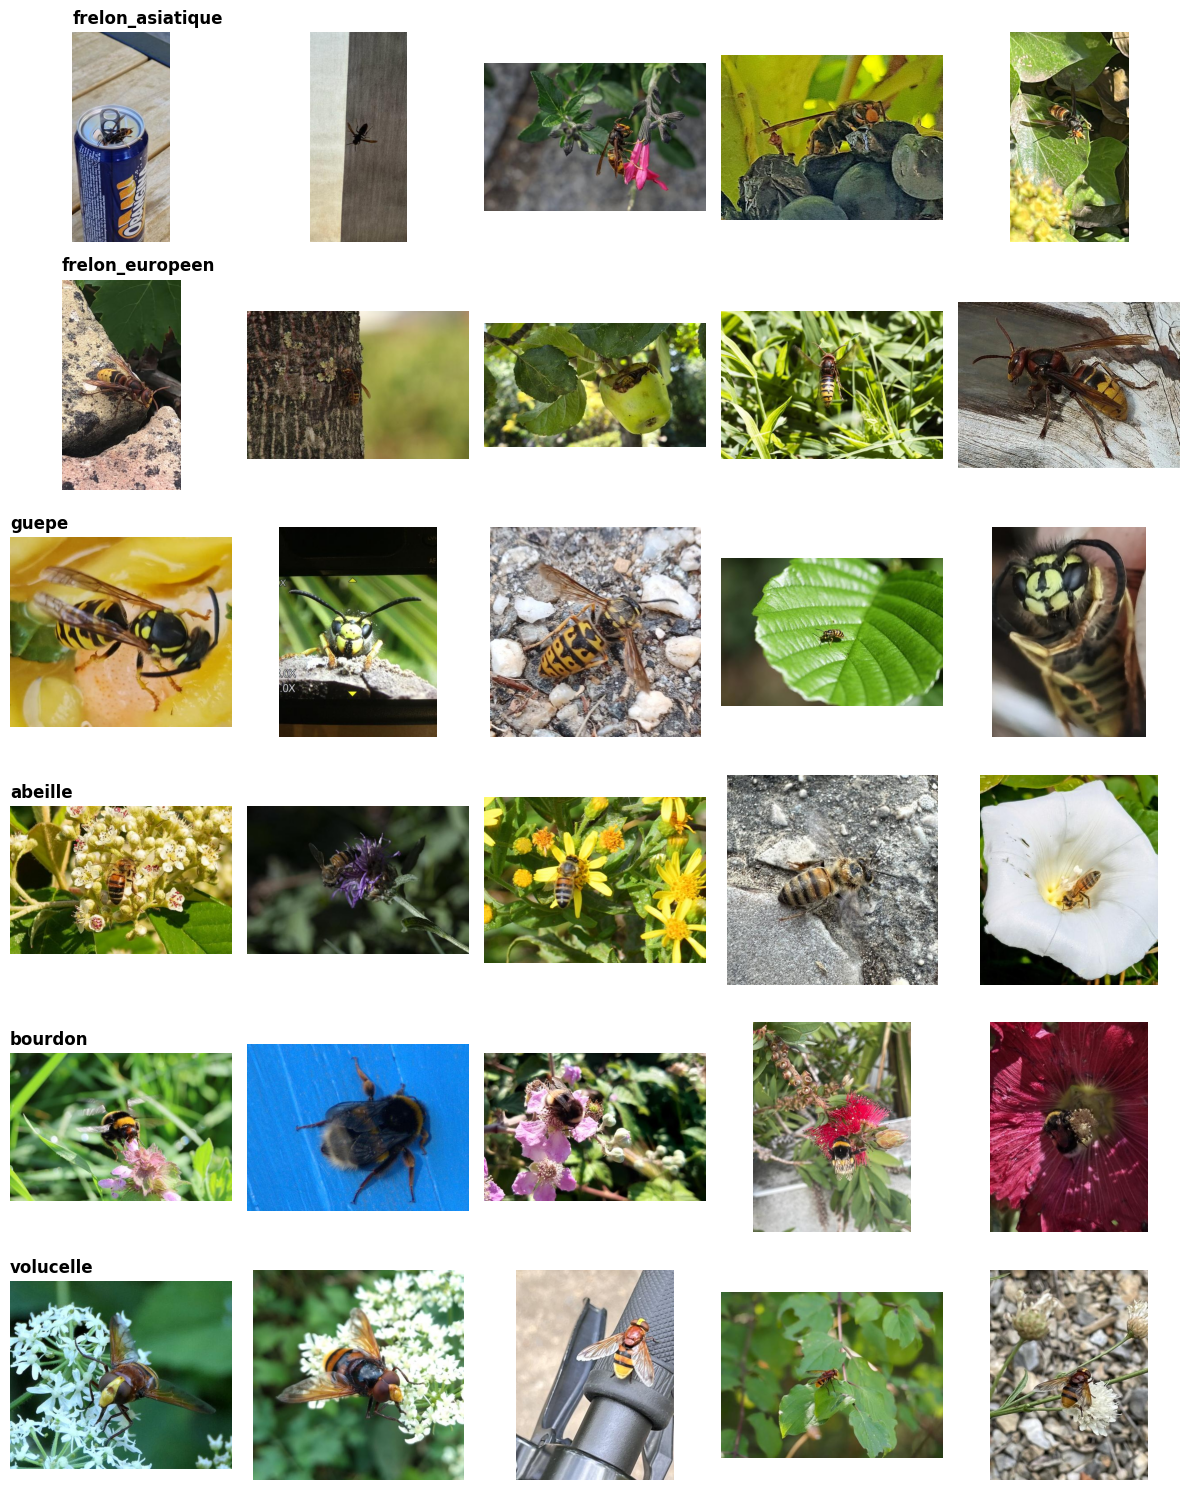

In [7]:
CLASSES = list(ESPECES.keys())

fig, axes = plt.subplots(len(CLASSES), 5, figsize=(12, 15))
for i, classe in enumerate(CLASSES):
    exemples = meta[meta["classe"] == classe].sample(5, random_state=SEED)
    for j, chemin in enumerate(exemples["fichier"]):
        axes[i, j].imshow(Image.open(chemin))
        axes[i, j].axis("off")
    axes[i, 0].set_title(classe, loc="left", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(PROJET, "outputs/eda_exemples.png"), dpi=120)
plt.show()

In [8]:
import hashlib

largeurs, hauteurs, empreintes = [], [], []
for chemin in meta["fichier"]:
    with Image.open(chemin) as img:
        largeurs.append(img.size[0])
        hauteurs.append(img.size[1])
    with open(chemin, "rb") as f:
        empreintes.append(hashlib.md5(f.read()).hexdigest())

meta["largeur"] = largeurs
meta["hauteur"] = hauteurs
meta["empreinte"] = empreintes

print(meta[["largeur", "hauteur"]].describe().round(0))
print("\nImages identiques (même contenu) :", meta["empreinte"].duplicated().sum())
print("Images trop petites (< 224 px)   :", ((meta["largeur"] < 224) | (meta["hauteur"] < 224)).sum())

       largeur  hauteur
count   2400.0   2400.0
mean     426.0    442.0
std       79.0     75.0
min      102.0    102.0
25%      375.0    375.0
50%      442.0    500.0
75%      500.0    500.0
max      500.0    500.0

Images identiques (même contenu) : 4
Images trop petites (< 224 px)   : 5


In [9]:
# 1) Photos identiques présentes dans plusieurs classes -> étiquette ambiguë, on les retire toutes
nb_classes = meta.groupby("empreinte")["classe"].nunique()
ambigues = nb_classes[nb_classes > 1].index
print("Photos dans plusieurs classes :", len(ambigues))

propre = meta[~meta["empreinte"].isin(ambigues)]

# 2) Doublons dans la même classe -> on garde une seule copie
propre = propre.drop_duplicates(subset="empreinte", keep="first")

# 3) Images trop petites -> retirées
propre = propre[(propre["largeur"] >= 224) & (propre["hauteur"] >= 224)]

print("Images avant nettoyage :", len(meta))
print("Images après nettoyage :", len(propre))
print(propre["classe"].value_counts())

propre.to_csv(os.path.join(PROJET, "data/metadonnees_propres.csv"), index=False)

Photos dans plusieurs classes : 0
Images avant nettoyage : 2400
Images après nettoyage : 2391
classe
volucelle           400
frelon_asiatique    399
abeille             399
frelon_europeen     398
guepe               398
bourdon             397
Name: count, dtype: int64


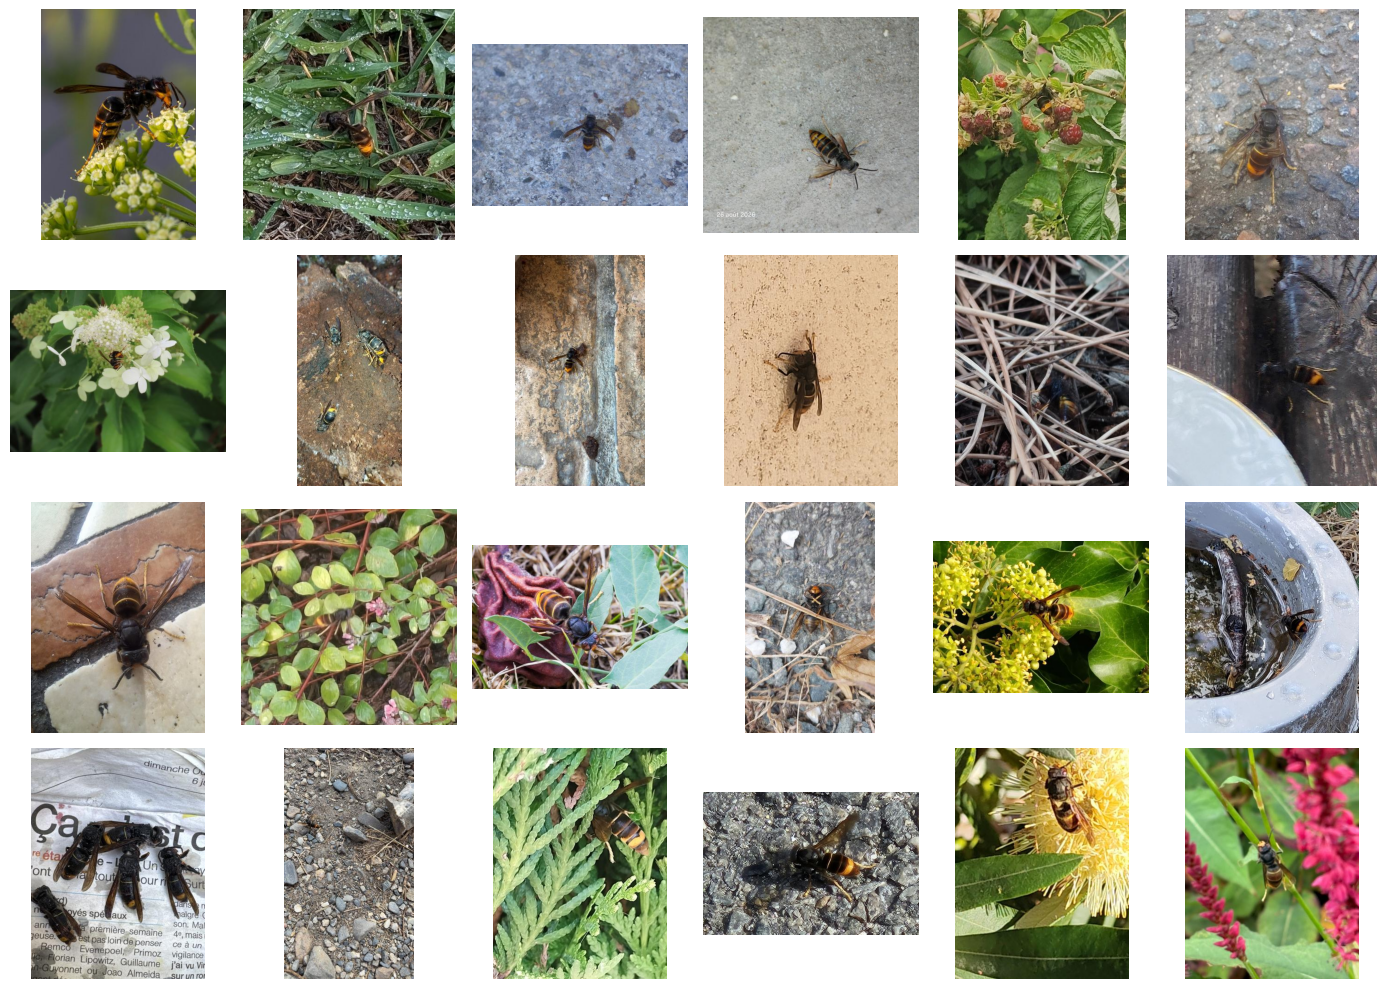

In [10]:
echantillon = propre[propre["classe"] == "frelon_asiatique"].sample(24, random_state=1)

fig, axes = plt.subplots(4, 6, figsize=(14, 10))
for ax, chemin in zip(axes.flat, echantillon["fichier"]):
    ax.imshow(Image.open(chemin))
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Préparation des données
### 3.1 Découpage : 70 % entraînement, 15 % validation, 15 % test
- Entraînement : le modèle apprend sur ces images.
- Validation : on surveille le modèle pendant l'entraînement pour choisir le meilleur.
- Test : jamais vu pendant le développement, utilisé UNE seule fois à la fin.
Le découpage est stratifié : chaque ensemble garde la même proportion de chaque classe.

In [11]:
import shutil
from sklearn.model_selection import train_test_split

# Copie des images sur le disque local de Colab : lecture beaucoup plus rapide que depuis le Drive
LOCAL = "/content/images"
if not os.path.exists(LOCAL):
    shutil.copytree(DOSSIER_IMAGES, LOCAL)

propre = pd.read_csv(os.path.join(PROJET, "data/metadonnees_propres.csv"))
propre["fichier_local"] = propre["fichier"].str.replace(DOSSIER_IMAGES, LOCAL, regex=False)

# Chaque classe reçoit un numéro (le modèle travaille avec des nombres, pas des mots)
CLASSES = list(ESPECES.keys())
CLASSE_VERS_ID = {classe: i for i, classe in enumerate(CLASSES)}
propre["label"] = propre["classe"].map(CLASSE_VERS_ID)

# Découpage en deux temps : 70 / 30, puis les 30 % coupés en deux (15 / 15)
train_df, reste = train_test_split(propre, test_size=0.30, stratify=propre["label"], random_state=SEED)
val_df, test_df = train_test_split(reste, test_size=0.50, stratify=reste["label"], random_state=SEED)

print(CLASSE_VERS_ID, "\n")
print(pd.DataFrame({
    "train": train_df["classe"].value_counts(),
    "val": val_df["classe"].value_counts(),
    "test": test_df["classe"].value_counts(),
}))

for nom, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    df.to_csv(os.path.join(PROJET, f"data/{nom}.csv"), index=False)

{'frelon_asiatique': 0, 'frelon_europeen': 1, 'guepe': 2, 'abeille': 3, 'bourdon': 4, 'volucelle': 5} 

                  train  val  test
classe                            
abeille             279   60    60
bourdon             278   60    59
frelon_asiatique    279   60    60
frelon_europeen     278   60    60
guepe               279   59    60
volucelle           280   60    60


### 3.2 Transformations
- Entraînement : augmentation de données (recadrage, retournement, rotation, luminosité)
  pour que le modèle voie chaque photo sous des formes un peu différentes à chaque époque.
- Validation et test : aucune augmentation, seulement le redimensionnement.
- Normalisation avec les statistiques d'ImageNet, car le ResNet a été pré-entraîné avec.

In [3]:
from torchvision import transforms

# Statistiques d'ImageNet : le ResNet pré-entraîné attend des images normalisées ainsi
MOYENNE = [0.485, 0.456, 0.406]
ECART_TYPE = [0.229, 0.224, 0.225]

transfo_train = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),       # recadrage modéré : on ne coupe pas l'insecte
    transforms.RandomHorizontalFlip(),                          # un frelon vu en miroir reste un frelon
    transforms.RandomRotation(20),                              # photos prises sous différents angles
    transforms.ColorJitter(brightness=0.2, contrast=0.2),       # lumière variable (soleil, ombre)
    transforms.ToTensor(),
    transforms.Normalize(MOYENNE, ECART_TYPE),
])

transfo_eval = transforms.Compose([
    transforms.Resize((224, 224)),                              # image entière, sans recadrage
    transforms.ToTensor(),
    transforms.Normalize(MOYENNE, ECART_TYPE),
])
print("Transformations prêtes")

Transformations prêtes


### 3.3 Dataset et DataLoaders
Le Dataset explique à PyTorch comment lire UNE image et son étiquette.
Le DataLoader regroupe les images par lots (batchs) de 32 et les mélange.

In [4]:
from torch.utils.data import Dataset, DataLoader


class InsectesDataset(Dataset):
    def __init__(self, df, transform):
        self.chemins = df["fichier_local"].tolist()
        self.labels = df["label"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.chemins)              # nombre total d'images

    def __getitem__(self, i):
        image = Image.open(self.chemins[i]).convert("RGB")
        return self.transform(image), self.labels[i]


BATCH = 32
train_loader = DataLoader(InsectesDataset(train_df, transfo_train), batch_size=BATCH, shuffle=True, num_workers=2)
val_loader = DataLoader(InsectesDataset(val_df, transfo_eval), batch_size=BATCH, shuffle=False, num_workers=2)
test_loader = DataLoader(InsectesDataset(test_df, transfo_eval), batch_size=BATCH, shuffle=False, num_workers=2)

images, labels = next(iter(train_loader))
print("Forme d'un batch d'images :", images.shape)
print("10 premières étiquettes   :", labels[:10].tolist())

Forme d'un batch d'images : torch.Size([32, 3, 224, 224])
10 premières étiquettes   : [4, 5, 0, 3, 3, 3, 3, 4, 0, 0]


### 3.4 Vérification : à quoi ressemblent les images que le modèle va voir ?

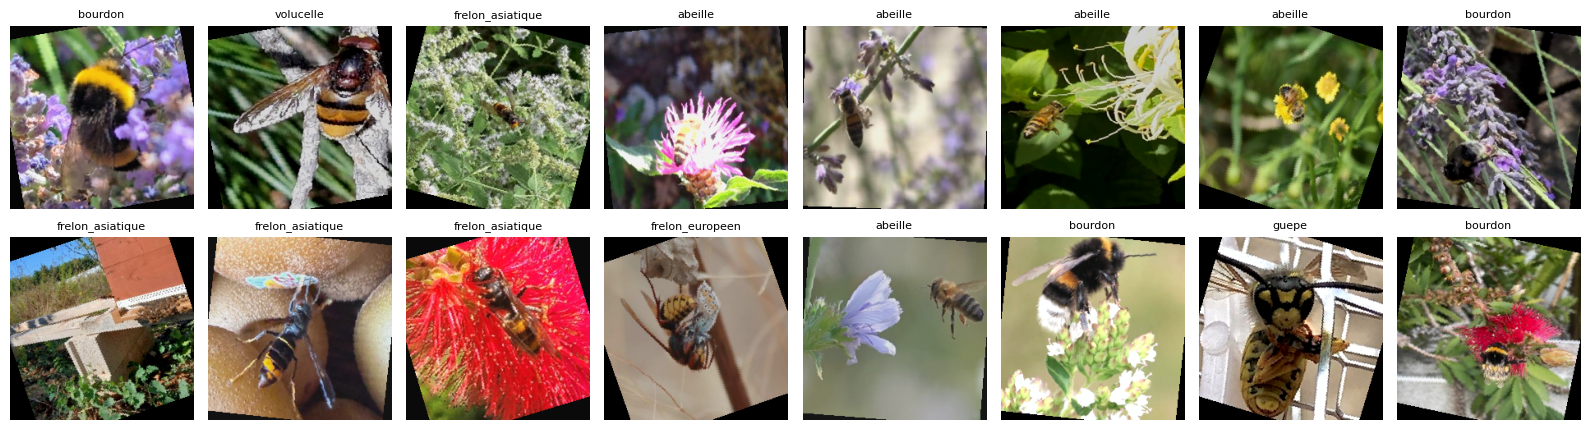

In [8]:
def pour_affichage(tensor):
    """Annule la normalisation pour pouvoir afficher l'image."""
    img = tensor.permute(1, 2, 0).numpy()        # [3, 224, 224] -> [224, 224, 3]
    img = img * np.array(ECART_TYPE) + np.array(MOYENNE)
    return np.clip(img, 0, 1)


fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for ax, img, label in zip(axes.flat, images, labels):
    ax.imshow(pour_affichage(img))
    ax.set_title(CLASSES[label], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(PROJET, "outputs/batch_augmente.png"), dpi=120)
plt.show()

In [5]:
# ---- Cellule de reprise : autonome, à lancer après une déconnexion ----
import os
import time
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch
from PIL import Image
from google.colab import drive

drive.mount("/content/drive")
PROJET = "/content/drive/MyDrive/projet_frelon"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DOSSIER_IMAGES = os.path.join(PROJET, "data/images")
LOCAL = "/content/images"
if not os.path.exists(LOCAL):
    shutil.copytree(DOSSIER_IMAGES, LOCAL)        # copie locale pour un entraînement rapide

CLASSES = ["frelon_asiatique", "frelon_europeen", "guepe", "abeille", "bourdon", "volucelle"]

train_df = pd.read_csv(os.path.join(PROJET, "data/train.csv"))
val_df = pd.read_csv(os.path.join(PROJET, "data/val.csv"))
test_df = pd.read_csv(os.path.join(PROJET, "data/test.csv"))

print("Appareil :", DEVICE)
print("Reprise OK :", len(train_df), "train |", len(val_df), "val |", len(test_df), "test")

Mounted at /content/drive
Appareil : cuda
Reprise OK : 1673 train | 359 val | 359 test


## 4. Modèle : fine-tuning d'un ResNet18
### 4.1 Chargement du modèle pré-entraîné et nouvelle tête de classification
Phase A : tout le ResNet est gelé, seule notre tête (512 → 256 → 6) est entraînée.

In [9]:
from torchvision import models
import torch.nn as nn

# ResNet18 avec les poids appris sur ImageNet
modele = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print("Dernière couche d'origine :", modele.fc)

# On gèle TOUS les poids du réseau pré-entraîné
for param in modele.parameters():
    param.requires_grad = False

# Notre tête de classification (créée après le gel, donc entraînable)
modele.fc = nn.Sequential(
    nn.Linear(512, 256),          # couche cachée : 512 caractéristiques -> 256
    nn.ReLU(),                    # non-linéarité
    nn.Dropout(0.3),              # éteint 30 % des neurones au hasard (anti-surapprentissage)
    nn.Linear(256, len(CLASSES)), # couche de sortie : un score par espèce
)
modele = modele.to(DEVICE)

total = sum(p.numel() for p in modele.parameters())
entrainables = sum(p.numel() for p in modele.parameters() if p.requires_grad)
print(f"Paramètres totaux      : {total:,}")
print(f"Paramètres entraînables : {entrainables:,} ({100 * entrainables / total:.1f} %)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


Dernière couche d'origine : Linear(in_features=512, out_features=1000, bias=True)
Paramètres totaux      : 11,309,382
Paramètres entraînables : 132,870 (1.2 %)


### 4.2 Boucle d'entraînement et d'évaluation
Pour chaque batch : prédiction → calcul de l'erreur → calcul des gradients → mise à jour des poids.


In [5]:
def entrainer_une_epoque(modele, loader, critere, optimiseur):
    modele.train()                                  # mode entraînement (Dropout actif)
    perte_totale, bonnes_reponses = 0.0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimiseur.zero_grad()                      # 1. remise à zéro des gradients
        sorties = modele(images)                    # 2. prédiction (forward)
        perte = critere(sorties, labels)            # 3. calcul de l'erreur
        perte.backward()                            # 4. calcul des gradients (backward)
        optimiseur.step()                           # 5. mise à jour des poids

        perte_totale += perte.item() * images.size(0)
        bonnes_reponses += (sorties.argmax(dim=1) == labels).sum().item()

    n = len(loader.dataset)
    return perte_totale / n, bonnes_reponses / n


@torch.no_grad()                                    # pas de gradients : on ne fait qu'évaluer
def evaluer(modele, loader, critere):
    modele.eval()                                   # mode évaluation (Dropout désactivé)
    perte_totale, bonnes_reponses = 0.0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        sorties = modele(images)
        perte_totale += critere(sorties, labels).item() * images.size(0)
        bonnes_reponses += (sorties.argmax(dim=1) == labels).sum().item()

    n = len(loader.dataset)
    return perte_totale / n, bonnes_reponses / n

print("Fonctions prêtes")

Fonctions prêtes


### 4.3 Phase A : entraînement de la tête seule (8 époques)
- Loss : CrossEntropyLoss, la loss standard en classification multi-classes.
- Optimiseur : Adam, learning rate 0.001.
- On sauvegarde le modèle uniquement quand la précision de validation s'améliore.

In [11]:
critere = nn.CrossEntropyLoss()
optimiseur = torch.optim.Adam(modele.fc.parameters(), lr=1e-3)   # seule la tête est optimisée

EPOQUES_A = 8
CHEMIN_MODELE = os.path.join(PROJET, "models/meilleur_modele.pt")
historique = []
meilleure_acc = 0.0

for epoque in range(1, EPOQUES_A + 1):
    debut = time.time()
    perte_train, acc_train = entrainer_une_epoque(modele, train_loader, critere, optimiseur)
    perte_val, acc_val = evaluer(modele, val_loader, critere)

    historique.append({"phase": "A", "epoque": epoque,
                       "perte_train": perte_train, "acc_train": acc_train,
                       "perte_val": perte_val, "acc_val": acc_val})

    marque = ""
    if acc_val > meilleure_acc:                     # meilleur modèle jusqu'ici -> on le sauvegarde
        meilleure_acc = acc_val
        torch.save(modele.state_dict(), CHEMIN_MODELE)
        marque = "  ← meilleur, sauvegardé"

    print(f"Époque {epoque} | train : perte {perte_train:.3f}, acc {acc_train:.1%} "
          f"| val : perte {perte_val:.3f}, acc {acc_val:.1%} | {time.time() - debut:.0f}s{marque}")

Époque 1 | train : perte 1.532, acc 37.8% | val : perte 1.236, acc 53.5% | 15s  ← meilleur, sauvegardé
Époque 2 | train : perte 1.192, acc 54.8% | val : perte 1.165, acc 54.9% | 14s  ← meilleur, sauvegardé
Époque 3 | train : perte 1.071, acc 59.0% | val : perte 1.094, acc 59.9% | 13s  ← meilleur, sauvegardé
Époque 4 | train : perte 1.013, acc 63.1% | val : perte 0.970, acc 64.6% | 11s  ← meilleur, sauvegardé
Époque 5 | train : perte 0.965, acc 65.1% | val : perte 1.037, acc 61.8% | 13s
Époque 6 | train : perte 0.934, acc 65.6% | val : perte 1.048, acc 61.3% | 14s
Époque 7 | train : perte 0.922, acc 66.5% | val : perte 1.086, acc 61.8% | 13s
Époque 8 | train : perte 0.901, acc 66.9% | val : perte 1.009, acc 63.0% | 13s


### 4.4 Phase B : fine-tuning du dernier bloc (layer4)
La phase A plafonne à environ 65 % : les caractéristiques d'ImageNet sont trop génériques.
On dégèle le dernier bloc du ResNet pour qu'il apprenne les détails propres à nos espèces.
Learning rates différenciés :
- layer4 : 0.0001 (petits pas, pour ajuster sans détruire ce qui a été appris sur ImageNet)
- tête : 0.001 (elle continue d'apprendre normalement)

In [12]:
# On repart du meilleur modèle de la phase A
modele.load_state_dict(torch.load(CHEMIN_MODELE))

# Dégel du dernier bloc du ResNet
for param in modele.layer4.parameters():
    param.requires_grad = True

entrainables = sum(p.numel() for p in modele.parameters() if p.requires_grad)
print(f"Paramètres entraînables : {entrainables:,} ({100 * entrainables / total:.1f} %)\n")

# Deux vitesses d'apprentissage différentes
optimiseur = torch.optim.Adam([
    {"params": modele.layer4.parameters(), "lr": 1e-4},
    {"params": modele.fc.parameters(), "lr": 1e-3},
])

EPOQUES_B = 10
for epoque in range(EPOQUES_A + 1, EPOQUES_A + EPOQUES_B + 1):
    debut = time.time()
    perte_train, acc_train = entrainer_une_epoque(modele, train_loader, critere, optimiseur)
    perte_val, acc_val = evaluer(modele, val_loader, critere)

    historique.append({"phase": "B", "epoque": epoque,
                       "perte_train": perte_train, "acc_train": acc_train,
                       "perte_val": perte_val, "acc_val": acc_val})

    marque = ""
    if acc_val > meilleure_acc:
        meilleure_acc = acc_val
        torch.save(modele.state_dict(), CHEMIN_MODELE)
        marque = "  ← meilleur, sauvegardé"

    print(f"Époque {epoque} | train : perte {perte_train:.3f}, acc {acc_train:.1%} "
          f"| val : perte {perte_val:.3f}, acc {acc_val:.1%} | {time.time() - debut:.0f}s{marque}")

Paramètres entraînables : 8,526,598 (75.4 %)

Époque 9 | train : perte 0.918, acc 66.4% | val : perte 0.885, acc 67.4% | 13s  ← meilleur, sauvegardé
Époque 10 | train : perte 0.647, acc 76.7% | val : perte 0.891, acc 69.1% | 13s  ← meilleur, sauvegardé
Époque 11 | train : perte 0.571, acc 78.2% | val : perte 0.870, acc 69.4% | 14s  ← meilleur, sauvegardé
Époque 12 | train : perte 0.402, acc 85.4% | val : perte 0.962, acc 69.9% | 14s  ← meilleur, sauvegardé
Époque 13 | train : perte 0.383, acc 86.7% | val : perte 0.903, acc 70.5% | 15s  ← meilleur, sauvegardé
Époque 14 | train : perte 0.333, acc 87.7% | val : perte 1.023, acc 67.7% | 13s
Époque 15 | train : perte 0.270, acc 90.6% | val : perte 0.991, acc 71.9% | 14s  ← meilleur, sauvegardé
Époque 16 | train : perte 0.201, acc 93.2% | val : perte 1.161, acc 69.9% | 11s
Époque 17 | train : perte 0.209, acc 92.2% | val : perte 1.080, acc 69.6% | 13s
Époque 18 | train : perte 0.172, acc 94.6% | val : perte 1.234, acc 69.1% | 13s


### 4.5 Courbes d'apprentissage (phases A et B)
La ligne pointillée marque le passage de la phase A à la phase B.

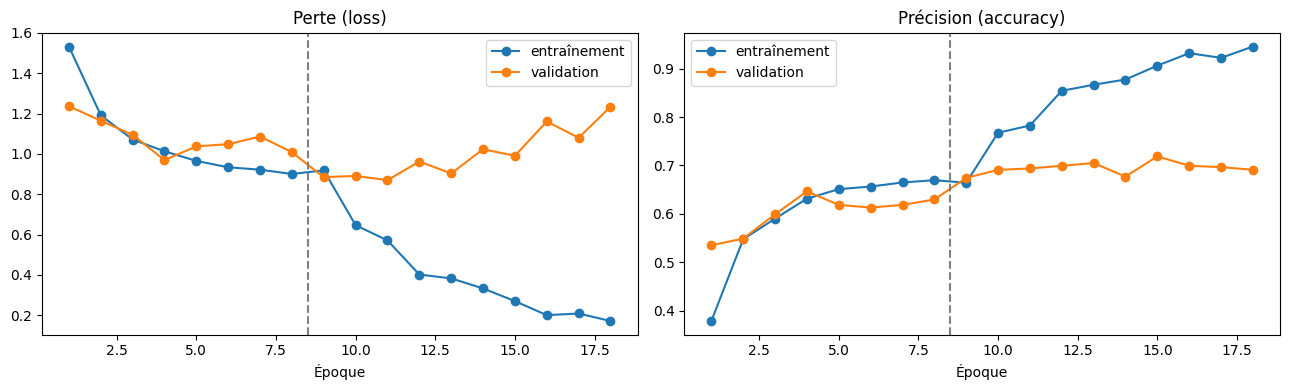

In [13]:
hist = pd.DataFrame(historique)
hist.to_csv(os.path.join(PROJET, "outputs/historique_v1.csv"), index=False)

# Copie de sécurité de la version 1 (les expériences suivantes écraseront meilleur_modele.pt)
shutil.copy(CHEMIN_MODELE, os.path.join(PROJET, "models/modele_v1_resnet18.pt"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist["epoque"], hist["perte_train"], marker="o", label="entraînement")
axes[0].plot(hist["epoque"], hist["perte_val"], marker="o", label="validation")
axes[0].set_title("Perte (loss)")

axes[1].plot(hist["epoque"], hist["acc_train"], marker="o", label="entraînement")
axes[1].plot(hist["epoque"], hist["acc_val"], marker="o", label="validation")
axes[1].set_title("Précision (accuracy)")

for ax in axes:
    ax.axvline(EPOQUES_A + 0.5, color="gray", linestyle="--")   # séparation phase A / phase B
    ax.set_xlabel("Époque")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PROJET, "outputs/courbes_v1.png"), dpi=150)
plt.show()

### 4.6 Diagnostic : quelles espèces le modèle confond-il ?
On utilise l'ensemble de VALIDATION (le test reste intact pour l'évaluation finale).

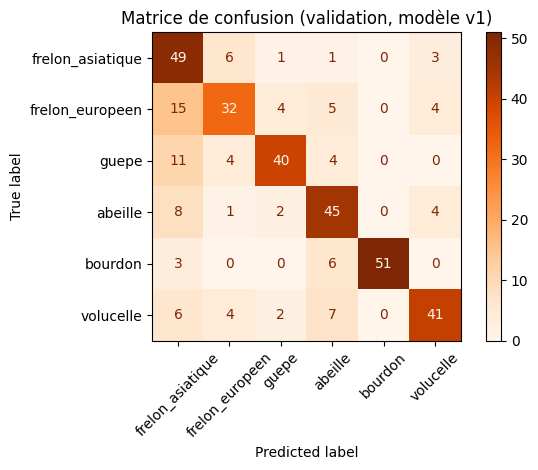

Précision par classe :
  frelon_asiatique  : 82%
  frelon_europeen   : 53%
  guepe             : 68%
  abeille           : 75%
  bourdon           : 85%
  volucelle         : 68%


In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

modele.load_state_dict(torch.load(CHEMIN_MODELE))     # meilleur modèle (71,9 %)
modele.eval()

vrais, predits = [], []
with torch.no_grad():
    for images, labels in val_loader:
        sorties = modele(images.to(DEVICE))
        predits += sorties.argmax(dim=1).cpu().tolist()
        vrais += labels.tolist()

cm = confusion_matrix(vrais, predits)
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(cmap="Oranges", xticks_rotation=45)
plt.title("Matrice de confusion (validation, modèle v1)")
plt.tight_layout()
plt.savefig(os.path.join(PROJET, "outputs/confusion_val_v1.png"), dpi=150)
plt.show()

print("Précision par classe :")
for i, classe in enumerate(CLASSES):
    print(f"  {classe:17} : {cm[i, i] / cm[i].sum():.0%}")

### 4.7 Vérification de l'hypothèse : à quoi ressemblent les erreurs ?
On affiche les photos de validation que le modèle a classées "frelon asiatique" alors
que c'était une autre espèce.

Nombre de photos prises à tort pour un frelon asiatique : 43


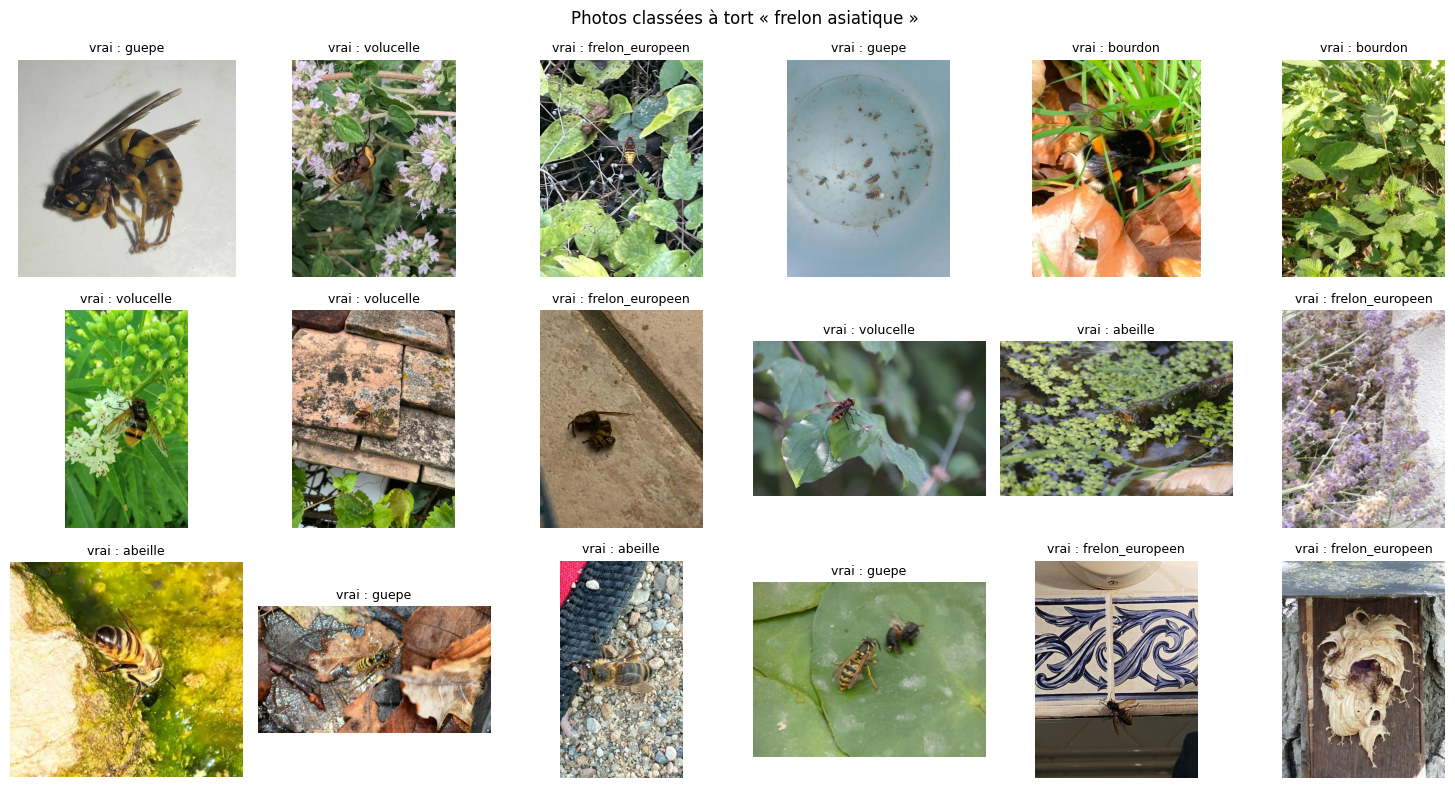

In [15]:
erreurs = [i for i, (v, p) in enumerate(zip(vrais, predits)) if p == 0 and v != 0]
print("Nombre de photos prises à tort pour un frelon asiatique :", len(erreurs))

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for ax, i in zip(axes.flat, erreurs[:18]):
    ax.imshow(Image.open(val_df.iloc[i]["fichier_local"]))
    ax.set_title(f"vrai : {CLASSES[vrais[i]]}", fontsize=9)
    ax.axis("off")
plt.suptitle("Photos classées à tort « frelon asiatique »")
plt.tight_layout()
plt.savefig(os.path.join(PROJET, "outputs/erreurs_frelon_asiatique.png"), dpi=120)
plt.show()

## 5. Version 2 : plus de données d'entraînement
Diagnostic v1 : surapprentissage + raccourci "insecte peu visible → frelon asiatique".
Remède : 400 nouvelles photos par classe, ajoutées UNIQUEMENT à l'entraînement.
Validation et test restent identiques → comparaison équitable entre v1 et v2.
Les nouvelles photos passent les mêmes filtres : pas de doublon, taille ≥ 224 px.

In [16]:
import hashlib
from io import BytesIO

API = "https://api.inaturalist.org/v1"
PLACE_ID = 6753                                   # France (trouvé à la cellule 4)
TAXONS = {"frelon_asiatique": 119019, "frelon_europeen": 54327, "guepe": 61356,
          "abeille": 47219, "bourdon": 57516, "volucelle": 343983}
LICENCES = "cc0,cc-by,cc-by-nc,cc-by-sa,cc-by-nc-sa,cc-by-nd,cc-by-nc-nd"
NB_NOUVELLES = 400


def lister_photos(taxon_id, nb):
    """Même fonction qu'à la cellule 5 : liste des photos d'une espèce, page par page."""
    photos, page = [], 1
    while len(photos) < nb:
        resultats = requests.get(f"{API}/observations", params={
            "taxon_id": taxon_id, "place_id": PLACE_ID, "quality_grade": "research",
            "photos": "true", "photo_license": LICENCES, "per_page": 200, "page": page,
        }).json()["results"]
        if not resultats:
            break
        for obs in resultats:
            photo = obs["photos"][0]
            photos.append({"obs_id": obs["id"],
                           "url": photo["url"].replace("square", "medium"),
                           "licence": photo["license_code"],
                           "auteur": photo["attribution"]})
        page += 1
        time.sleep(1)
    return photos[:nb]


# Ce qu'on possède déjà : on ne veut ni la même observation, ni la même image
deja_vus = set(pd.read_csv(os.path.join(PROJET, "data/metadonnees.csv"))["obs_id"])
empreintes_connues = set(pd.read_csv(os.path.join(PROJET, "data/metadonnees_propres.csv"))["empreinte"])

nouvelles = []
for classe, taxon_id in TAXONS.items():
    dossier = os.path.join(DOSSIER_IMAGES, classe)
    photos = lister_photos(taxon_id, 1000)          # on en liste plus, car certaines seront écartées
    nb_ajout = 0

    for p in photos:
        if nb_ajout >= NB_NOUVELLES:
            break
        if p["obs_id"] in deja_vus:                 # déjà téléchargée en v1
            continue
        try:
            contenu = requests.get(p["url"], timeout=20).content
            img = Image.open(BytesIO(contenu)).convert("RGB")
        except Exception:
            continue
        if img.size[0] < 224 or img.size[1] < 224:  # trop petite
            continue

        chemin = os.path.join(dossier, f"{p['obs_id']}.jpg")
        img.save(chemin)
        with open(chemin, "rb") as f:
            empreinte = hashlib.md5(f.read()).hexdigest()
        if empreinte in empreintes_connues:         # image identique à une image existante
            os.remove(chemin)
            continue

        empreintes_connues.add(empreinte)
        nouvelles.append({"classe": classe, "fichier": chemin, **p,
                          "largeur": img.size[0], "hauteur": img.size[1], "empreinte": empreinte})
        nb_ajout += 1

    print(f"{classe:17} : {nb_ajout} nouvelles images")

ajout = pd.DataFrame(nouvelles)
ajout.to_csv(os.path.join(PROJET, "data/metadonnees_ajout_v2.csv"), index=False)
print("\nTotal ajouté :", len(ajout))

frelon_asiatique  : 400 nouvelles images
frelon_europeen   : 400 nouvelles images
guepe             : 400 nouvelles images
abeille           : 400 nouvelles images
bourdon           : 400 nouvelles images
volucelle         : 400 nouvelles images

Total ajouté : 2400


### 5.1 Nouvel ensemble d'entraînement = ancien train + nouvelles images

In [17]:
# Copie locale des nouvelles images, comme pour les anciennes
ajout["fichier_local"] = ajout["fichier"].str.replace(DOSSIER_IMAGES, LOCAL, regex=False)
for source, destination in zip(ajout["fichier"], ajout["fichier_local"]):
    shutil.copy(source, destination)

ajout["label"] = ajout["classe"].map({classe: i for i, classe in enumerate(CLASSES)})

train_v2_df = pd.concat([train_df, ajout], ignore_index=True)
train_v2_df.to_csv(os.path.join(PROJET, "data/train_v2.csv"), index=False)

print(pd.DataFrame({
    "train_v1": train_df["classe"].value_counts(),
    "train_v2": train_v2_df["classe"].value_counts(),
    "val (inchangé)": val_df["classe"].value_counts(),
}))

                  train_v1  train_v2  val (inchangé)
classe                                              
abeille                279       679              60
bourdon                278       678              60
frelon_asiatique       279       679              60
frelon_europeen        278       678              60
guepe                  279       679              59
volucelle              280       680              60


### 5.2 Entraînement v2 (mêmes réglages que la v1, seules les données changent)
- creer_modele() : ResNet18 pré-entraîné, gelé, avec notre tête 512 → 256 → 6 (comme la cellule 15)
- lancer_phase() : la boucle des époques avec sauvegarde du meilleur modèle (comme les cellules 17 et 18)

In [18]:
train_loader_v2 = DataLoader(InsectesDataset(train_v2_df, transfo_train),
                             batch_size=BATCH, shuffle=True, num_workers=2)
CHEMIN_V2 = os.path.join(PROJET, "models/modele_v2_resnet18.pt")


def creer_modele():
    """ResNet18 pré-entraîné, entièrement gelé, avec notre tête de classification."""
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in m.parameters():
        param.requires_grad = False
    m.fc = nn.Sequential(
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, len(CLASSES)),
    )
    return m.to(DEVICE)


def lancer_phase(modele, optimiseur, loader, epoques, phase, historique, meilleure_acc, chemin):
    """Entraîne sur plusieurs époques et sauvegarde le modèle quand la validation s'améliore."""
    for epoque in epoques:
        debut = time.time()
        perte_train, acc_train = entrainer_une_epoque(modele, loader, critere, optimiseur)
        perte_val, acc_val = evaluer(modele, val_loader, critere)
        historique.append({"phase": phase, "epoque": epoque,
                           "perte_train": perte_train, "acc_train": acc_train,
                           "perte_val": perte_val, "acc_val": acc_val})
        marque = ""
        if acc_val > meilleure_acc:
            meilleure_acc = acc_val
            torch.save(modele.state_dict(), chemin)
            marque = "  ← meilleur, sauvegardé"
        print(f"Époque {epoque} | train : perte {perte_train:.3f}, acc {acc_train:.1%} "
              f"| val : perte {perte_val:.3f}, acc {acc_val:.1%} | {time.time() - debut:.0f}s{marque}")
    return meilleure_acc


torch.manual_seed(SEED)
modele_v2 = creer_modele()                 # on repart de zéro (poids ImageNet), comme la v1
historique_v2 = []
meilleure_v2 = 0.0

print("--- Phase A : tête seule ---")
optimiseur = torch.optim.Adam(modele_v2.fc.parameters(), lr=1e-3)
meilleure_v2 = lancer_phase(modele_v2, optimiseur, train_loader_v2, range(1, 9), "A",
                            historique_v2, meilleure_v2, CHEMIN_V2)

print("\n--- Phase B : dégel de layer4 ---")
modele_v2.load_state_dict(torch.load(CHEMIN_V2))
for param in modele_v2.layer4.parameters():
    param.requires_grad = True
optimiseur = torch.optim.Adam([
    {"params": modele_v2.layer4.parameters(), "lr": 1e-4},
    {"params": modele_v2.fc.parameters(), "lr": 1e-3},
])
meilleure_v2 = lancer_phase(modele_v2, optimiseur, train_loader_v2, range(9, 19), "B",
                            historique_v2, meilleure_v2, CHEMIN_V2)

pd.DataFrame(historique_v2).to_csv(os.path.join(PROJET, "outputs/historique_v2.csv"), index=False)
print(f"\nMeilleure précision en validation : v1 = 71.9 %  |  v2 = {meilleure_v2:.1%}")

--- Phase A : tête seule ---
Époque 1 | train : perte 1.308, acc 48.6% | val : perte 1.103, acc 59.3% | 30s  ← meilleur, sauvegardé
Époque 2 | train : perte 1.060, acc 60.2% | val : perte 1.027, acc 61.6% | 26s  ← meilleur, sauvegardé
Époque 3 | train : perte 0.997, acc 62.8% | val : perte 1.018, acc 62.4% | 27s  ← meilleur, sauvegardé
Époque 4 | train : perte 0.968, acc 64.1% | val : perte 0.954, acc 64.3% | 28s  ← meilleur, sauvegardé
Époque 5 | train : perte 0.905, acc 66.0% | val : perte 0.980, acc 63.2% | 27s
Époque 6 | train : perte 0.875, acc 66.7% | val : perte 0.973, acc 63.2% | 25s
Époque 7 | train : perte 0.870, acc 67.5% | val : perte 0.978, acc 63.2% | 27s
Époque 8 | train : perte 0.862, acc 67.3% | val : perte 0.975, acc 63.8% | 27s

--- Phase B : dégel de layer4 ---
Époque 9 | train : perte 0.811, acc 70.0% | val : perte 0.765, acc 71.0% | 26s  ← meilleur, sauvegardé
Époque 10 | train : perte 0.579, acc 78.6% | val : perte 0.744, acc 72.4% | 26s  ← meilleur, sauvegardé
É

Reprise


In [2]:
# ---- Cellule de reprise : autonome, à lancer après une déconnexion ----
import os
import time
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch
import torch.nn as nn
from torchvision import models
from PIL import Image
from google.colab import drive

drive.mount("/content/drive")
PROJET = "/content/drive/MyDrive/projet_frelon"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DOSSIER_IMAGES = os.path.join(PROJET, "data/images")
LOCAL = "/content/images"
if not os.path.exists(LOCAL):
    shutil.copytree(DOSSIER_IMAGES, LOCAL)        # copie locale (v1 + v2) pour un entraînement rapide

CLASSES = ["frelon_asiatique", "frelon_europeen", "guepe", "abeille", "bourdon", "volucelle"]

train_df = pd.read_csv(os.path.join(PROJET, "data/train.csv"))
train_v2_df = pd.read_csv(os.path.join(PROJET, "data/train_v2.csv"))
val_df = pd.read_csv(os.path.join(PROJET, "data/val.csv"))
test_df = pd.read_csv(os.path.join(PROJET, "data/test.csv"))

print("Appareil :", DEVICE)
print("Reprise OK :", len(train_v2_df), "train v2 |", len(val_df), "val |", len(test_df), "test")

ValueError: mount failed

## 6. Version 3 : EfficientNet-B2 en 288 px
Diagnostic v2 : la phase A plafonne à 64 % (l'œil du ResNet18 est trop limité)
et les erreurs concernent surtout des insectes minuscules (résolution trop faible).
Remède : EfficientNet-B2 (meilleur sur ImageNet : 80,6 % contre 69,8 %),
avec des images en 288 px au lieu de 224.
Tout le reste est identique à la v2 (données, tête, phases, learning rates).

In [6]:
from torchvision import transforms

TAILLE = 288    # taille d'entrée prévue pour EfficientNet-B2

transfo_train_v3 = transforms.Compose([
    transforms.RandomResizedCrop(TAILLE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MOYENNE, ECART_TYPE),
])
transfo_eval_v3 = transforms.Compose([
    transforms.Resize((TAILLE, TAILLE)),
    transforms.ToTensor(),
    transforms.Normalize(MOYENNE, ECART_TYPE),
])

train_loader_v3 = DataLoader(InsectesDataset(train_v2_df, transfo_train_v3),
                             batch_size=BATCH, shuffle=True, num_workers=2)
val_loader_v3 = DataLoader(InsectesDataset(val_df, transfo_eval_v3),
                           batch_size=BATCH, shuffle=False, num_workers=2)

critere = nn.CrossEntropyLoss()
CHEMIN_V3 = os.path.join(PROJET, "models/modele_v3_efficientnet_b2.pt")


def creer_modele_v3():
    """EfficientNet-B2 pré-entraîné, entièrement gelé, avec notre tête de classification."""
    m = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)
    for param in m.parameters():
        param.requires_grad = False
    m.classifier = nn.Sequential(
        nn.Linear(1408, 256),          # EfficientNet-B2 résume l'image en 1408 nombres
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, len(CLASSES)),
    )
    return m.to(DEVICE)


def lancer_phase(modele, optimiseur, loader_train, loader_val, epoques, phase,
                 historique, meilleure_acc, chemin):
    """Entraîne sur plusieurs époques et sauvegarde le modèle quand la validation s'améliore."""
    for epoque in epoques:
        debut = time.time()
        perte_train, acc_train = entrainer_une_epoque(modele, loader_train, critere, optimiseur)
        perte_val, acc_val = evaluer(modele, loader_val, critere)
        historique.append({"phase": phase, "epoque": epoque,
                           "perte_train": perte_train, "acc_train": acc_train,
                           "perte_val": perte_val, "acc_val": acc_val})
        marque = ""
        if acc_val > meilleure_acc:
            meilleure_acc = acc_val
            torch.save(modele.state_dict(), chemin)
            marque = "  ← meilleur, sauvegardé"
        print(f"Époque {epoque} | train : perte {perte_train:.3f}, acc {acc_train:.1%} "
              f"| val : perte {perte_val:.3f}, acc {acc_val:.1%} | {time.time() - debut:.0f}s{marque}")
    return meilleure_acc


torch.manual_seed(SEED)
modele_v3 = creer_modele_v3()
historique_v3 = []
meilleure_v3 = 0.0

total = sum(p.numel() for p in modele_v3.parameters())
print(f"Paramètres totaux : {total:,}\n")

print("--- Phase A : tête seule ---")
optimiseur = torch.optim.Adam(modele_v3.classifier.parameters(), lr=1e-3)
meilleure_v3 = lancer_phase(modele_v3, optimiseur, train_loader_v3, val_loader_v3, range(1, 9), "A",
                            historique_v3, meilleure_v3, CHEMIN_V3)

print("\n--- Phase B : dégel des derniers blocs (features[6:]) ---")
modele_v3.load_state_dict(torch.load(CHEMIN_V3))
for param in modele_v3.features[6:].parameters():
    param.requires_grad = True
entrainables = sum(p.numel() for p in modele_v3.parameters() if p.requires_grad)
print(f"Paramètres entraînables : {entrainables:,} ({100 * entrainables / total:.1f} %)")

optimiseur = torch.optim.Adam([
    {"params": modele_v3.features[6:].parameters(), "lr": 1e-4},
    {"params": modele_v3.classifier.parameters(), "lr": 1e-3},
])
meilleure_v3 = lancer_phase(modele_v3, optimiseur, train_loader_v3, val_loader_v3, range(9, 19), "B",
                            historique_v3, meilleure_v3, CHEMIN_V3)

pd.DataFrame(historique_v3).to_csv(os.path.join(PROJET, "outputs/historique_v3.csv"), index=False)
print(f"\nMeilleure précision en validation : v1 = 71.9 % | v2 = 76.6 % | v3 = {meilleure_v3:.1%}")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 56.6MB/s]


Paramètres totaux : 8,063,240

--- Phase A : tête seule ---
Époque 1 | train : perte 1.072, acc 61.1% | val : perte 0.982, acc 61.8% | 45s  ← meilleur, sauvegardé
Époque 2 | train : perte 0.774, acc 71.3% | val : perte 0.877, acc 67.4% | 39s  ← meilleur, sauvegardé
Époque 3 | train : perte 0.701, acc 75.1% | val : perte 0.895, acc 66.3% | 42s
Époque 4 | train : perte 0.673, acc 75.2% | val : perte 0.880, acc 67.4% | 38s
Époque 5 | train : perte 0.637, acc 76.0% | val : perte 0.878, acc 67.1% | 40s
Époque 6 | train : perte 0.614, acc 76.9% | val : perte 0.885, acc 67.1% | 41s
Époque 7 | train : perte 0.578, acc 79.0% | val : perte 0.866, acc 67.7% | 38s  ← meilleur, sauvegardé
Époque 8 | train : perte 0.552, acc 79.3% | val : perte 0.863, acc 68.8% | 41s  ← meilleur, sauvegardé

--- Phase B : dégel des derniers blocs (features[6:]) ---
Paramètres entraînables : 6,645,376 (82.4 %)
Époque 9 | train : perte 0.477, acc 82.7% | val : perte 0.604, acc 80.2% | 42s  ← meilleur, sauvegardé
Époqu

## 7. Évaluation finale sur le jeu de test (une seule fois)
Le jeu de test n'a jamais été utilisé jusqu'ici. Son score mesure la vraie
performance du modèle sur des photos inédites. Aucune modification après ce point.

PRÉCISION SUR LE TEST : 82.7%

                  precision    recall  f1-score   support

frelon_asiatique      0.726     0.883     0.797        60
 frelon_europeen      0.742     0.817     0.778        60
           guepe      0.926     0.833     0.877        60
         abeille      0.846     0.733     0.786        60
         bourdon      0.883     0.898     0.891        59
       volucelle      0.889     0.800     0.842        60

        accuracy                          0.827       359
       macro avg      0.835     0.827     0.828       359
    weighted avg      0.835     0.827     0.828       359



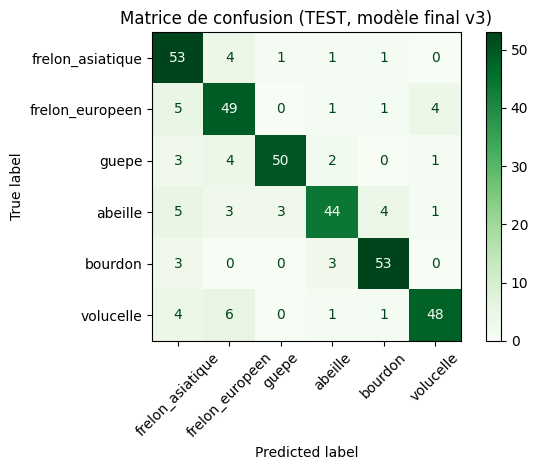

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

test_loader_v3 = DataLoader(InsectesDataset(test_df, transfo_eval_v3),
                            batch_size=BATCH, shuffle=False, num_workers=2)

modele_v3.load_state_dict(torch.load(CHEMIN_V3))     # meilleur modèle v3 (époque 15)
modele_v3.eval()

vrais, predits = [], []
with torch.no_grad():
    for images, labels in test_loader_v3:
        sorties = modele_v3(images.to(DEVICE))
        predits += sorties.argmax(dim=1).cpu().tolist()
        vrais += labels.tolist()

precision_test = np.mean(np.array(vrais) == np.array(predits))
print(f"PRÉCISION SUR LE TEST : {precision_test:.1%}\n")
print(classification_report(vrais, predits, target_names=CLASSES, digits=3))

cm = confusion_matrix(vrais, predits)
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(cmap="Greens", xticks_rotation=45)
plt.title("Matrice de confusion (TEST, modèle final v3)")
plt.tight_layout()
plt.savefig(os.path.join(PROJET, "outputs/confusion_test_v3.png"), dpi=150)
plt.show()

reprise sans cpu

In [3]:
# ---- REPRISE COMPLÈTE (sans GPU) : prépare tout pour la cellule 28 ----
import os
import json
import time
import shutil
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from google.colab import drive

# 1) Connexion au Drive et réglages de base
drive.mount("/content/drive")
PROJET = "/content/drive/MyDrive/projet_frelon"
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2) Copie locale des images
DOSSIER_IMAGES = os.path.join(PROJET, "data/images")
LOCAL = "/content/images"
if not os.path.exists(LOCAL):
    shutil.copytree(DOSSIER_IMAGES, LOCAL)

# 3) Classes et tableaux de données
CLASSES = ["frelon_asiatique", "frelon_europeen", "guepe", "abeille", "bourdon", "volucelle"]
val_df = pd.read_csv(os.path.join(PROJET, "data/val.csv"))
test_df = pd.read_csv(os.path.join(PROJET, "data/test.csv"))

# 4) Transformations (comme à l'entraînement de la v3)
MOYENNE = [0.485, 0.456, 0.406]
ECART_TYPE = [0.229, 0.224, 0.225]
transfo_eval_v3 = transforms.Compose([
    transforms.Resize((288, 288)),
    transforms.ToTensor(),
    transforms.Normalize(MOYENNE, ECART_TYPE),
])

# 5) Dataset (comme la cellule 13)
class InsectesDataset(Dataset):
    def __init__(self, df, transform):
        self.chemins = df["fichier_local"].tolist()
        self.labels = df["label"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.chemins)

    def __getitem__(self, i):
        image = Image.open(self.chemins[i]).convert("RGB")
        return self.transform(image), self.labels[i]

BATCH = 32

# 6) Fonction d'évaluation (comme la cellule 16)
@torch.no_grad()
def evaluer(modele, loader, critere):
    modele.eval()
    perte_totale, bonnes_reponses = 0.0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        sorties = modele(images)
        perte_totale += critere(sorties, labels).item() * images.size(0)
        bonnes_reponses += (sorties.argmax(dim=1) == labels).sum().item()
    n = len(loader.dataset)
    return perte_totale / n, bonnes_reponses / n

print("Appareil :", DEVICE)
print("Reprise complète OK :", len(val_df), "val |", len(test_df), "test")

Mounted at /content/drive
Appareil : cpu
Reprise complète OK : 359 val | 359 test


## 8. Préparation de l'application Streamlit
On prépare le dossier app_streamlit/ qui sera déposé sur GitHub :
- le modèle en demi-précision (float16), pour passer sous la limite de 25 Mo de GitHub ;
- un fichier de configuration (classes, taille d'image, normalisation) ;
- 6 photos d'exemple du jeu de test, une par espèce, avec leurs crédits.

In [4]:
import json
import torch.nn as nn

APP = os.path.join(PROJET, "app_streamlit")
os.makedirs(os.path.join(APP, "exemples"), exist_ok=True)

# 1) Modèle en demi-précision (float16) : fichier deux fois plus léger
poids = torch.load(os.path.join(PROJET, "models/modele_v3_efficientnet_b2.pt"), map_location="cpu")
poids_legers = {nom: (t.half() if t.is_floating_point() else t) for nom, t in poids.items()}
chemin_modele_app = os.path.join(APP, "modele_frelon.pt")
torch.save(poids_legers, chemin_modele_app)
print(f"Taille du modèle allégé : {os.path.getsize(chemin_modele_app) / 1e6:.1f} Mo")

# 2) Vérification : le modèle allégé donne-t-il les mêmes résultats ? (sur la VALIDATION)
modele_leger = models.efficientnet_b2(weights=None)
modele_leger.classifier = nn.Sequential(nn.Linear(1408, 256), nn.ReLU(), nn.Dropout(0.3),
                                        nn.Linear(256, len(CLASSES)))
modele_leger.load_state_dict({nom: (t.float() if t.is_floating_point() else t)
                              for nom, t in torch.load(chemin_modele_app).items()})
modele_leger = modele_leger.to(DEVICE)

val_loader_app = DataLoader(InsectesDataset(val_df, transfo_eval_v3), batch_size=BATCH, shuffle=False)
_, acc_leger = evaluer(modele_leger, val_loader_app, nn.CrossEntropyLoss())
print(f"Validation, modèle allégé : {acc_leger:.1%}  (modèle d'origine : 83.8 %)")

# 3) Fichier de configuration lu par l'application
config = {
    "classes": CLASSES,
    "noms": {
        "frelon_asiatique": "Frelon asiatique (Vespa velutina)",
        "frelon_europeen": "Frelon européen (Vespa crabro)",
        "guepe": "Guêpe (Vespula sp.)",
        "abeille": "Abeille domestique (Apis mellifera)",
        "bourdon": "Bourdon terrestre (Bombus terrestris)",
        "volucelle": "Volucelle zonée (Volucella zonaria)",
    },
    "taille": 288,
    "moyenne": MOYENNE,
    "ecart_type": ECART_TYPE,
    "precision_test": 0.827,
}
with open(os.path.join(APP, "config.json"), "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

# 4) Une photo d'exemple par espèce (jeu de test), licences sans "nd" (modification interdite)
credits = []
for classe in CLASSES:
    candidates = test_df[(test_df["classe"] == classe) & (~test_df["licence"].str.contains("nd"))]
    choix = candidates.sample(1, random_state=SEED).iloc[0]
    destination = os.path.join(APP, "exemples", f"{classe}.jpg")
    shutil.copy(choix["fichier"], destination)
    credits.append({"fichier": f"{classe}.jpg", "auteur": choix["auteur"], "licence": choix["licence"]})
pd.DataFrame(credits).to_csv(os.path.join(APP, "exemples", "credits.csv"), index=False)

print("\nContenu du dossier de l'application :")
for racine, _, fichiers in os.walk(APP):
    for f in fichiers:
        print("  ", os.path.relpath(os.path.join(racine, f), APP))

Taille du modèle allégé : 16.4 Mo
Validation, modèle allégé : 83.8%  (modèle d'origine : 83.8 %)

Contenu du dossier de l'application :
   modele_frelon.pt
   config.json
   exemples/frelon_asiatique.jpg
   exemples/frelon_europeen.jpg
   exemples/guepe.jpg
   exemples/abeille.jpg
   exemples/bourdon.jpg
   exemples/volucelle.jpg
   exemples/credits.csv
